In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# read csv file 
dataset = pd.read_csv("C:\\Datasets_ml\\Social_Network_Ads.csv")
dataset

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [3]:
# i don't have need to estimated salary so i have to drop
dataset.drop(columns = ["EstimatedSalary"],inplace = True)

In [4]:
dataset

,Age,Purchased
0,19,0
1,35,0
2,26,0
3,27,0
4,19,0
...,...,...
395,46,1
396,51,1
397,50,1
398,36,0


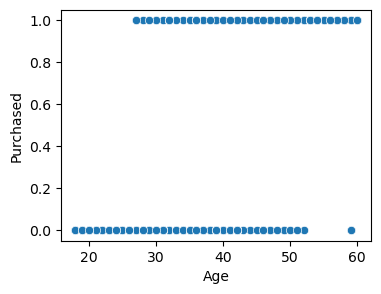

In [5]:
# plot the scatterplot graph
plt.figure(figsize = (4,3))
sns.scatterplot(x = "Age", y="Purchased", data = dataset)
plt.show()

In [6]:
# so our data really like a logistic regression

In [7]:
# check null values
dataset.isnull().sum()
dataset.columns

Index(['Age', 'Purchased'], dtype='object')

In [8]:
# split training and testing data
X = dataset[["Age"]]
y = dataset["Purchased"]

# now split data in the form of test and train
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)

print("Trained Age")
print(X_train)
print("\nTested Age")
print(X_test)
print("\nTrained purchased")
print(y_train)
print("\nTested Puchased")
print(y_test)

Trained Age
     Age
205   47
354   36
3     27
264   48
194   28
..   ...
299   46
22    48
72    20
15    29
168   29

[320 rows x 1 columns]

Tested Age
     Age
94    29
32    21
225   37
157   29
356   54
..   ...
188   35
223   60
65    24
262   55
186   20

[80 rows x 1 columns]

Trained purchased
205    0
354    1
3      0
264    1
194    0
      ..
299    1
22     1
72     0
15     0
168    1
Name: Purchased, Length: 320, dtype: int64

Tested Puchased
94     0
32     0
225    0
157    0
356    1
      ..
188    0
223    1
65     0
262    1
186    0
Name: Purchased, Length: 80, dtype: int64


In [9]:
# prediction of dataset using Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train,y_train)



LogisticRegression()

In [10]:
# accuracy
model.score(X_train,y_train)*100

83.125

In [11]:
# test model at age =40
model.predict([[40]])

C:\Users\jiyad\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

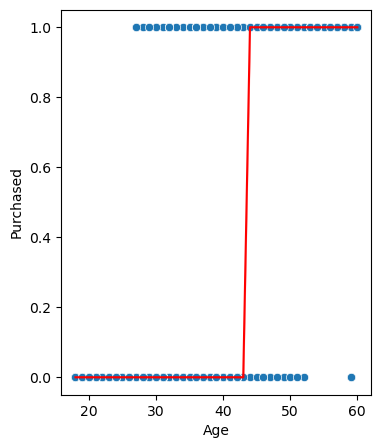

In [12]:
# plot line graph that show the predicted values 
purchased_prediction = model.predict(X)
plt.figure(figsize = (4,5))
sns.scatterplot(x = "Age", y = "Purchased", data =  dataset)
sns.lineplot(x = "Age",y=purchased_prediction,data = dataset,color = "red")
plt.show()